#pip install all the necessary libraries

In [3]:
pip install numpy scipy pymanopt autograd POT  matplotlib scikit-learn pywavefront pandas networkx quantecon requests openpyxl

#Begin by collection the initial sets X and Y
We define
$X$ as the daily end-of-day price history over the past 1,256 trading days for the 50 largest companies by market capitalization in the U.S. equity market (S&P 500 constituents).


Similarly, we define
$Y$ as the corresponding end-of-day price history over the same period for the 50 largest companies by market capitalization in the Japanese equity market, drawn primarily from the Nikkei 225 index (though not limited exclusively to its constituents).


Namely, we have
$$
X = (x_1, \dots, x_{50}), ~~~Y = (y_1, \dots, y_{50})
$$
Where
$$
x_i = (P_i(1), \dots, P_i(1256)) \in \mathbb{R}^{1256}
$$
$$
y_j = (\tilde{P}_j(1), \dots, \tilde{P}_j(1256)) \in \mathbb{R}^{1256}
$$
And $P_i(t), \tilde{P}_j(t)$ are the values at the end of the trade day $t$ of the i'th and j'th companies of the American and Japanese markets respectively.
##Normalize X and Y
We normalize the trade history of each company by the value of it's stock at the end of the first trade day, so all the companies start value 1.


We do that in order to neutralize scaling problems that can occur from differences in the currencies (\$ to &yen;) and different starting points.

Fetching S&P 500 constituents from SlickCharts...


/tmp/ipython-input-4239957287.py:72: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500_df = pd.read_html(resp_sp.text)[0]


Building X for S&P 500 top-50 by index weight...
Added S&P 500: Nvidia (NVDA), total: 1
Added S&P 500: Apple Inc. (AAPL), total: 2
Added S&P 500: Microsoft (MSFT), total: 3
Added S&P 500: Amazon (AMZN), total: 4
Added S&P 500: Alphabet Inc. (Class A) (GOOGL), total: 5
Added S&P 500: Alphabet Inc. (Class C) (GOOG), total: 6
Added S&P 500: Meta Platforms (META), total: 7
Added S&P 500: Tesla, Inc. (TSLA), total: 8
Added S&P 500: Broadcom (AVGO), total: 9
Added S&P 500: Berkshire Hathaway (BRK-B), total: 10
Added S&P 500: Walmart (WMT), total: 11
Added S&P 500: Lilly (Eli) (LLY), total: 12
Added S&P 500: JPMorgan Chase (JPM), total: 13
Added S&P 500: ExxonMobil (XOM), total: 14
Added S&P 500: Visa Inc. (V), total: 15
Added S&P 500: Johnson & Johnson (JNJ), total: 16
Added S&P 500: Micron Technology (MU), total: 17
Added S&P 500: Mastercard (MA), total: 18
Added S&P 500: Oracle Corporation (ORCL), total: 19
Added S&P 500: Costco (COST), total: 20
Added S&P 500: AbbVie (ABBV), total: 21
Add

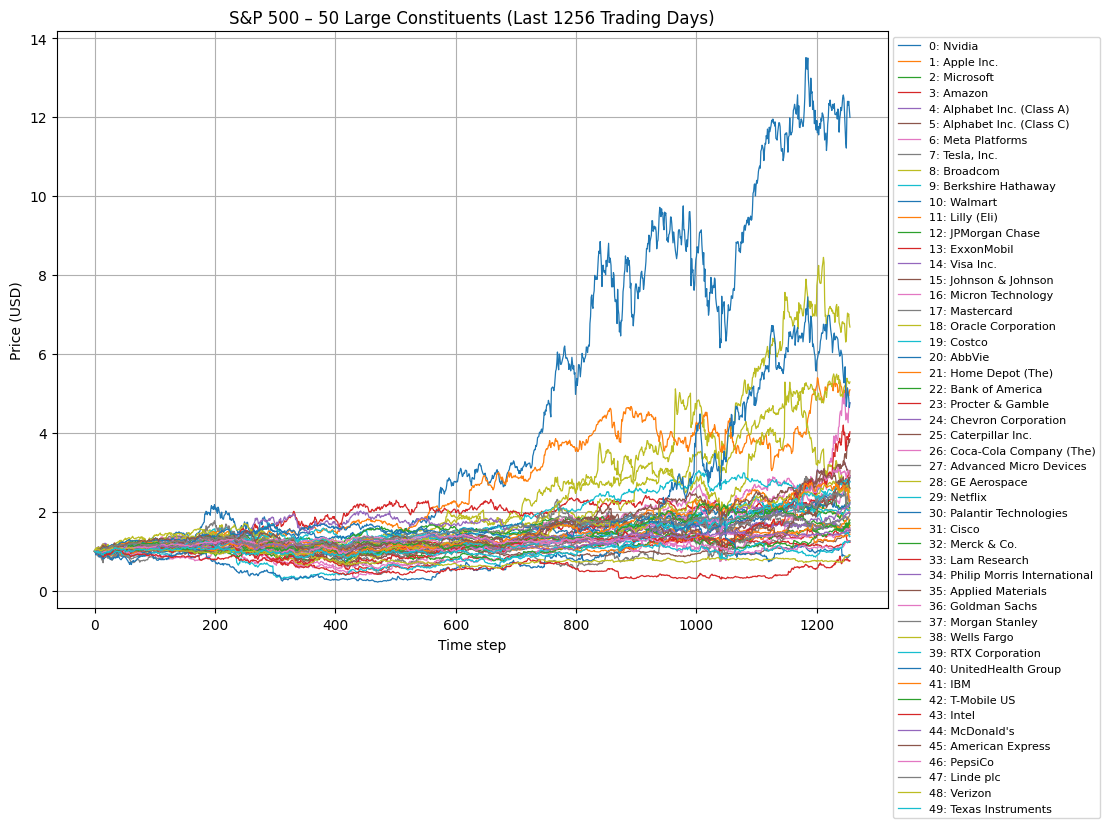

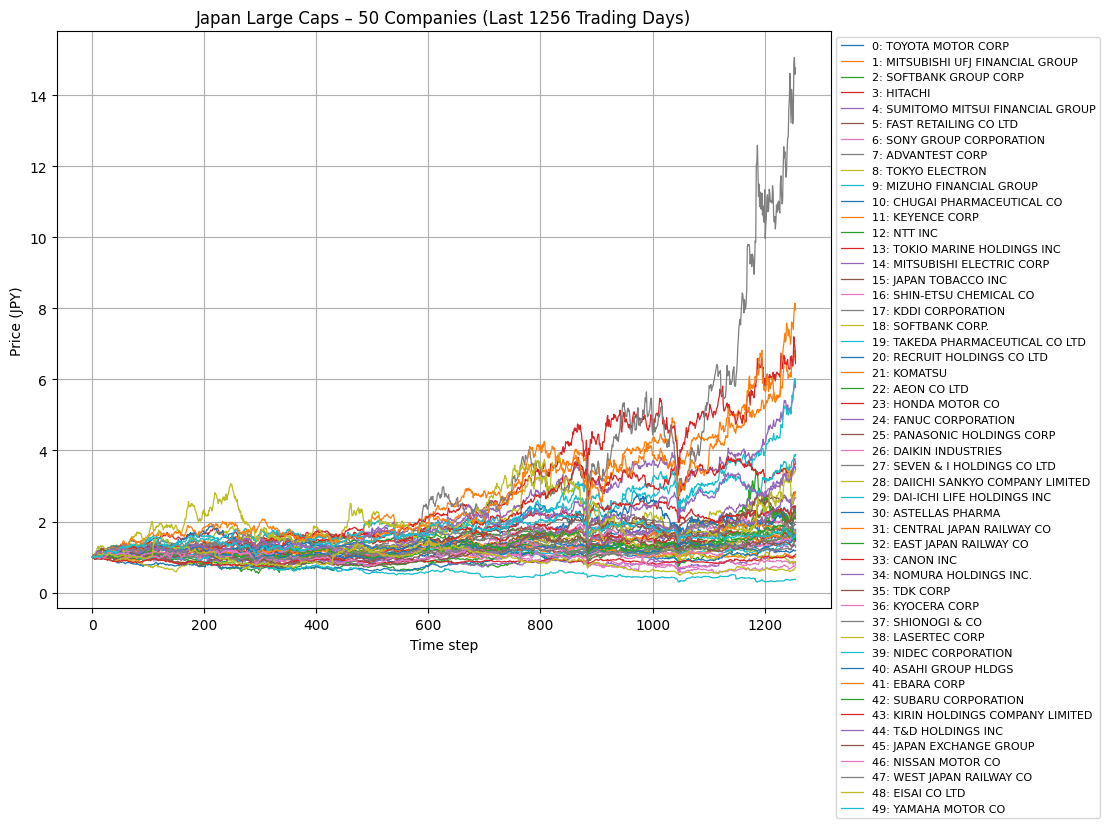

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import requests

# ----------------------------
# Global settings
# ----------------------------
N_COMPANIES = 50
T = 1256  # number of trading-day samples (~5 years)

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0 Safari/537.36"
    )
}

# ----------------------------
# Helper: get last T closes
# ----------------------------
def get_last_T_closes(ticker, T, period="6y"):
    """
    Download daily OHLC for `ticker`, and return the last T closing prices
    as a 1D numpy array of shape (T,).
    Returns None if not enough data.
    """
    try:
        hist = yf.download(
            ticker,
            period=period,
            interval="1d",
            auto_adjust=False,
            progress=False,
        )
    except Exception as e:
        print(f"Failed to download {ticker}: {e}")
        return None

    # Ensure we have a 'Close' column
    if "Close" not in hist or hist["Close"].dropna().empty:
        print(f"No closing prices for {ticker}")
        return None

    closes = hist["Close"].dropna().values  # should be 1D

    if len(closes) < T:
        print(f"Not enough data for {ticker}: {len(closes)} < {T}")
        return None

    # Force 1D array of length T
    arr = np.asarray(closes[-T:]).reshape(-1)
    if arr.shape[0] != T:
        print(f"Unexpected shape for {ticker}: {arr.shape}")
        return None

    return arr


# ============================================================
# 1) S&P 500 – top 50 by weight (from SlickCharts) → X
# ============================================================

print("Fetching S&P 500 constituents from SlickCharts...")

sp500_url = "https://www.slickcharts.com/sp500"
resp_sp = requests.get(sp500_url, headers=headers)
resp_sp.raise_for_status()

sp500_df = pd.read_html(resp_sp.text)[0]
# Typical columns: ['#', 'Company', 'Symbol', 'Weight', 'Price', 'Chg', '% Chg']
sp500_df.rename(columns={"Symbol": "Ticker", "Company": "Name"}, inplace=True)

def fix_us_ticker(t):
    # yfinance uses "-" instead of "." (BRK.B -> BRK-B, etc.)
    return str(t).replace(".", "-").strip()

sp500_df["YF_Ticker"] = sp500_df["Ticker"].apply(fix_us_ticker)

sp500_vectors = []
sp500_names = []
sp500_tickers_effective = []

print("Building X for S&P 500 top-50 by index weight...")
for _, row in sp500_df.iterrows():
    if len(sp500_vectors) >= N_COMPANIES:
        break

    yf_ticker = row["YF_Ticker"]
    name = row["Name"]

    x_i = get_last_T_closes(yf_ticker, T)
    if x_i is None:
        continue

    # x_i should be shape (T,)
    sp500_vectors.append(x_i)
    sp500_names.append(name)
    sp500_tickers_effective.append(yf_ticker)
    print(f"Added S&P 500: {name} ({yf_ticker}), total: {len(sp500_vectors)}")

if len(sp500_vectors) < N_COMPANIES:
    raise RuntimeError(
        f"Only collected {len(sp500_vectors)} S&P 500 series with length {T}."
    )

# Build X as [50, 1256]
X = np.array(sp500_vectors)
if X.shape != (N_COMPANIES, T):
    # If it somehow came out flattened, fix it
    if X.size == N_COMPANIES * T:
        X = X.reshape(N_COMPANIES, T)
    else:
        raise RuntimeError(f"Unexpected X shape {X.shape} with size {X.size}")

print("X shape:", X.shape)

sp500_index_to_name = {i: name for i, name in enumerate(sp500_names)}
print("\nS&P 500 index-to-name mapping (first 10):")
for i in range(min(10, N_COMPANIES)):
    print(i, "->", sp500_index_to_name[i])


# ============================================================
# 2) Japanese large caps (proxy for “top 50 index members”) → Y
# ============================================================

japan_large_caps = [
    "7203.T",  # Toyota Motor
    "7267.T",  # Honda Motor
    "7201.T",  # Nissan Motor
    "7270.T",  # Subaru
    "6501.T",  # Hitachi
    "6503.T",  # Mitsubishi Electric
    "6971.T",  # Kyocera
    "6954.T",  # Fanuc
    "7731.T",  # Nikon
    "7751.T",  # Canon
    "8035.T",  # Tokyo Electron
    "6758.T",  # Sony Group
    "6857.T",  # Advantest
    "6861.T",  # Keyence
    "6920.T",  # Lasertec
    "6752.T",  # Panasonic
    "6762.T",  # TDK
    "8306.T",  # Mitsubishi UFJ Financial
    "8316.T",  # Sumitomo Mitsui Financial
    "8411.T",  # Mizuho Financial Group
    "8604.T",  # Nomura Holdings
    "8766.T",  # Tokio Marine
    "8750.T",  # Dai-ichi Life
    "8795.T",  # T&D Holdings
    "8697.T",  # Japan Exchange Group
    "9432.T",  # NTT
    "9433.T",  # KDDI
    "9434.T",  # SoftBank Corp
    "9984.T",  # SoftBank Group
    "3382.T",  # Seven & i Holdings
    "9983.T",  # Fast Retailing
    "8267.T",  # Aeon
    "2914.T",  # Japan Tobacco
    "2503.T",  # Kirin
    "2502.T",  # Asahi
    "4502.T",  # Takeda
    "4519.T",  # Chugai Pharma
    "4568.T",  # Daiichi Sankyo
    "4507.T",  # Shionogi
    "4523.T",  # Eisai
    "4063.T",  # Shin-Etsu Chemical
    "6367.T",  # Daikin
    "6301.T",  # Komatsu
    "6361.T",  # Ebara
    "7272.T",  # Yamaha Motor
    "9064.T",  # Yamato Holdings
    "6098.T",  # Recruit Holdings
    "9020.T",  # JR East
    "9021.T",  # JR West
    "9022.T",  # JR Central
    "6594.T",  # Nidec
    "4061.T",  # Denka
    "4503.T",  # Astellas Pharma
]


japan_large_caps = sorted(set(japan_large_caps))
japan_df = pd.DataFrame({"YF_Ticker": japan_large_caps})

print("\nFetching market caps for Japanese large caps...")
market_caps = []
names = []

for ticker in japan_df["YF_Ticker"]:
    try:
        tk = yf.Ticker(ticker)
        info = tk.info
        mc = info.get("marketCap", None)
        name = info.get("shortName", ticker)
    except Exception as e:
        print(f"Failed info for {ticker}: {e}")
        mc = None
        name = ticker

    market_caps.append(mc)
    names.append(name)

japan_df["MarketCap"] = market_caps
japan_df["Name"] = names

# Filter valid market caps and sort
japan_df = japan_df.dropna(subset=["MarketCap"])
japan_df = japan_df.sort_values("MarketCap", ascending=False)

candidate_japan = japan_df.head(max(N_COMPANIES, 70))

japan_vectors = []
japan_names = []
japan_tickers_effective = []

print("Building Y for Japanese large caps (top 50 by marketCap within our list)...")
for _, row in candidate_japan.iterrows():
    if len(japan_vectors) >= N_COMPANIES:
        break

    yf_ticker = row["YF_Ticker"]
    name = row["Name"]

    y_i = get_last_T_closes(yf_ticker, T)
    if y_i is None:
        continue

    japan_vectors.append(y_i)
    japan_names.append(name)
    japan_tickers_effective.append(yf_ticker)
    print(f"Added Japan: {name} ({yf_ticker}), total: {len(japan_vectors)}")

if len(japan_vectors) < N_COMPANIES:
    raise RuntimeError(
        f"Only collected {len(japan_vectors)} Japanese series with length {T}."
    )

Y = np.array(japan_vectors)
if Y.shape != (N_COMPANIES, T):
    if Y.size == N_COMPANIES * T:
        Y = Y.reshape(N_COMPANIES, T)
    else:
        raise RuntimeError(f"Unexpected Y shape {Y.shape} with size {Y.size}")

print("Y shape:", Y.shape)

japan_index_to_name = {i: name for i, name in enumerate(japan_names)}
print("\nJapan index-to-name mapping (first 10):")
for i in range(min(10, N_COMPANIES)):
    print(i, "->", japan_index_to_name[i])


X_norm = X / X[:, [0]]
Y_norm = Y / Y[:, [0]]


# ============================================================
# 3) Plotting X and Y (with legends)
# ============================================================

time_axis = np.arange(T)

# -----------------------
# Plot X (S&P 500)
# -----------------------
plt.figure(figsize=(14, 8))
for i in range(N_COMPANIES):
    plt.plot(time_axis, X_norm[i, :], linewidth=0.9,
             label=f"{i}: {sp500_index_to_name[i]}")
plt.title("S&P 500 – 50 Large Constituents (Last 1256 Trading Days)")
plt.xlabel("Time step")
plt.ylabel("Price (USD)")
plt.grid(True)

# Place legend outside plot area
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout(rect=[0, 0, 0.8, 1])  # make room for legend
plt.show()

# -----------------------
# Plot Y (Japan)
# -----------------------
plt.figure(figsize=(14, 8))
for i in range(N_COMPANIES):
    plt.plot(time_axis, Y_norm[i, :], linewidth=0.9,
             label=f"{i}: {japan_index_to_name[i]}")
plt.title("Japan Large Caps – 50 Companies (Last 1256 Trading Days)")
plt.xlabel("Time step")
plt.ylabel("Price (JPY)")
plt.grid(True)

plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()


#Next we decide on a measure that will indicate the behaviour of each stock.
##We can either use
$$
R^{X}_i(t+1) =log(x_i(t+1)) - log(x_i(t)),
$$

$$
R^{Y}_j(t+1) =log(y_j(t+1)) - log(y_j(t)).
$$

##Or calculate instead
$$
R_i^{X}(t+1) = \frac{x_i(t+1) - x_i(t)}{x_i(t)},
$$

$$
R_j^{Y}(t+1) = \frac{y_j(t+1) - y_j(t)}{y_j(t)}.
$$

###For the second option calculate as well
$$
P_{market} = \frac{1}{n}\sum_{k=1}^nP_k, ~~~~R_{market}(t) =\frac{P_{market}(t) - P_{market}(t-1)}{P_{market}(t-1)}.
$$

In [5]:
import numpy as np

def compute_R(x, y, log=False):

  if log:
      # X and Y must be of shape (50, 1256)

      # Compute log-returns along the time axis
      log_R_X = np.log(x[:, 1:]) - np.log(x[:, :-1])   # shape (50, 1255)
      log_R_Y = np.log(y[:, 1:]) - np.log(y[:, :-1])   # shape (50, 1255)

      return log_R_X, log_R_Y, None, None, None, None
  else:
      # Compute log-returns along the time axis
      R_X = (x[:, 1:] - x[:, :-1])/x[:, :-1]   # shape (50, 1255)
      R_Y = (y[:, 1:] - y[:, :-1])/ y[:, :-1]   # shape (50, 1255)

      P_X_market = np.mean(X_norm, axis=0)
      P_Y_market = np.mean(Y_norm, axis=0)
      R_X_market = P_X_market[1:]/ P_X_market[:-1] - 1.0
      R_Y_market = P_Y_market[1:]/ P_Y_market[:-1] - 1.0
      return R_X, R_Y, R_X_market, R_Y_market, P_X_market, P_Y_market

R_X, R_Y, R_X_market, R_Y_market, P_X_market, P_Y_market = compute_R(X_norm, Y_norm)

#The point clouds $X$ and $Y$ for the experiment
We take our point clouds $X$ and $Y$ to be
$$
X = \{R_1^X,\dots,R^X_{50}\} \subset \mathbb{R}^{1255}, ~~~ Y = \{R^Y_1, \dots, R^Y_{50} \} \subset \mathbb{R}^{1255}
$$

#Next, introduce a notion of similarity between two stocks in a cloud
$$
W\_X_{ij} = \frac{Cov(R^X_i, R^X_j)}{\sigma_i^X \sigma_j^X},
$$


$$
W\_Y_{ij} = \frac{Cov(R^Y_i, R^Y_j)}{\sigma_i^Y \sigma_j^Y}.
$$
On top of these we furher calculate the graph Laplacians $L_X$ and $L_Y$.

In [6]:
import numpy as np
def compute_W(r_x, r_y):
    # R_X, R_Y are assumed to have shape (50, 1255)
    N = r_x.shape[1]           # 1255
    denom = N - 1              # 1254

    # ----- For X -----
    # Mean per asset (over time)
    mean_RX = r_x.mean(axis=1, keepdims=True)          # (50, 1)

    # Centered returns
    RX_centered = r_x - mean_RX                        # (50, 1255)

    # Covariance matrix (50 x 50)
    Cov_X = (RX_centered @ RX_centered.T) / denom      # (50, 50)

    # Variances per asset (diagonal)
    var_X = np.diag(Cov_X)                             # (50,)
    sigma_X = np.sqrt(var_X)                           # (50,)



    # Correlation / normalized covariance matrix W_X
    W_X = Cov_X / (sigma_X[:, None] * sigma_X[None, :])


    # ----- For Y -----
    mean_RY = r_y.mean(axis=1, keepdims=True)          # (50, 1)
    RY_centered = r_y - mean_RY                        # (50, 1255)

    Cov_Y = (RY_centered @ RY_centered.T) / denom      # (50, 50)
    var_Y = np.diag(Cov_Y)                             # (50,)
    sigma_Y = np.sqrt(var_Y)                           # (50,)



    W_Y = Cov_Y / (sigma_Y[:, None] * sigma_Y[None, :])

    return W_X, W_Y

W_X, W_Y = compute_W(R_X, R_Y)

W_X = np.minimum(W_X, 1)
W_Y = np.minimum(W_Y, 1)



#Next we calculate a different similarity measure on the basis of which we calculate the distance profiles of each cloud
$$
W\_X_{ij} = \frac{ Cov(R_i^X, \frac{P_j}{P_m} \cdot R^X_j)} {Var(R_{market}^X)},
$$
$$
W\_Y_{ij} = \frac{ Cov(R^Y_i, \frac{\tilde{P}_j}{P^X_{market}} \cdot R^Y_j)} {Var(R_{market}^Y)}.
$$

In [7]:
import numpy as np

# R_X, R_Y are assumed to have shape (50, 1255)
def compute_W_for_C(r_x, r_y, x, y, p_x_market, p_y_market, r_x_market, r_y_market):

    N = r_x.shape[1]           # 1255
    denom = N - 1              # 1254

    # ----- For X -----
    # Mean per asset (over time)

    RX_PX_market = (r_x * x[:, :-1])/(p_x_market[:-1])
    mean_RX_PX_market = RX_PX_market.mean(axis=1, keepdims=True)
    RX_PX_market_centered = RX_PX_market - mean_RX_PX_market


    mean_RX = r_x.mean(axis=1, keepdims=True)          # (50, 1)

    # Centered returns
    RX_centered = r_x - mean_RX                        # (50, 1255)

    mean_RX_market = r_x_market.mean()
    RX_market_centered = R_X_market - mean_RX_market

    var_RX_market = RX_market_centered @ RX_market_centered.T / denom


    # Covariance matrix (50 x 50)
    Cov_X = (RX_centered @ RX_PX_market_centered.T) / denom      # (50, 50)



    # Correlation / normalized covariance matrix W_X
    W_X_matching = Cov_X / var_RX_market

    # ----- For Y -----
    RY_PY_market = (r_y * y[:, :-1])/(p_y_market[:-1])
    mean_RY_PY_market = RY_PY_market.mean(axis=1, keepdims=True)
    RY_PY_market_centered = RY_PY_market - mean_RY_PY_market


    mean_RY = r_y.mean(axis=1, keepdims=True)          # (50, 1)
    RY_centered = r_y - mean_RY                        # (50, 1255)

    mean_RY_market = r_y_market.mean()
    RY_market_centered = R_Y_market - mean_RY_market

    var_RY_market = RY_market_centered @ RY_market_centered.T / denom



    # Covariance matrix (50 x 50)
    Cov_Y = (RY_centered @ (RY_PY_market_centered).T) / denom      # (50, 50)


    W_Y_matching = Cov_Y / var_RY_market
    return W_X_matching, W_Y_matching

W_X_matching, W_Y_matching = compute_W_for_C(R_X, R_Y, X_norm, Y_norm, P_X_market, P_Y_market, R_X_market, R_Y_market)

#Next, we transform
$$
W_{ij} ⟶ \sqrt{2(1 - W_{ij})}
$$
So, the values of the potential similarity between points in a cloud move from $[-1, 1]$ to $[0, 2]$.

In [8]:
import numpy as np

# Assume W_X and W_Y are (50, 50) correlation-like matrices with values in [-1, 1]

# Elementwise transformation
DX = np.sqrt(2 * (1 - W_X))
DY = np.sqrt(2 * (1 - W_Y))



#Our method

# Calculate $L_X$ and $L_Y$
Notice- we want to have more control on the radius of similarity and hence he firt transform
$$
W_{ij} ⟶ \exp (-(\frac{W_{ij}}{2\sigma})^2),
$$

On top of which we calculate the graph Laplacian according to
$$
L = \text{diag}(W\mathbf{1}_n) - W.
$$

In [13]:
# Asign the value of sigma
sigma = 0.5

# Assume for now same amount of points in both clouds
n = X.shape[0]



# Step 2: Compute the similarity matrices W_X, W_Y based on the gaussian similarity function.
W_X_adjace = np.exp(-DX**2/(2*sigma**2))
W_Y_adjace = np.exp(-DY**2/(2*sigma**2))

# Step 3: Compute the degrees of points in both X and Y
row_sums_X = np.sum(W_X_adjace, axis=1)
row_sums_Y = np.sum(W_Y_adjace, axis=1)


# Create diagonal matrices D_X, D_Y from row sums
D_X = np.diag(row_sums_X)
D_Y = np.diag(row_sums_Y)


# Now the laplacians L_X, L_Y:
L_X = D_X - W_X_adjace
L_Y = D_Y - W_Y_adjace

# Also compute the non-uniform distributions instead on the uniformly weighted distance profiles
sum_X = np.sum(row_sums_X)
sum_Y = np.sum(row_sums_Y)
a = row_sums_X / sum_X
b = row_sums_Y / sum_Y


#Calculate the $\beta$ parameter for each company in each cloud for later comparison

$$
\beta_i = \frac{Cov(R^X_i, R^X_{market})}{Var(R^X_{market})}, ~~~~ \tilde{\beta}_j = \frac{Cov(R^Y_i, R^Y_{market})}{Var(R^Y_{market})}.
$$

In [10]:
def compute_beta(r_x, r_y, r_x_market, r_y_market):

    N = r_x.shape[1]           # 1255
    denom = N - 1              # 1254

    # ----- For X -----
    # Mean per asset (over time)

    mean_RX_market = r_x_market.mean()
    RX_market_centered = r_x_market - mean_RX_market


    mean_RX = r_x.mean(axis=1, keepdims=True)          # (50, 1)

    # Centered returns
    RX_centered = r_x - mean_RX                        # (50, 1255)

    var_RX_market = RX_market_centered @ RX_market_centered.T / denom


    # Covariance matrix (50 x 50)
    Cov_X = (RX_centered @ RX_market_centered.T) / denom      # (50, 50)

    # # Variances per asset (diagonal)
    # var_X = np.diag(Cov_X)                             # (50,)
    # sigma_X = np.sqrt(var_X)                           # (50,)
    # print(f'This is sigma_X:{sigma_X}')


    # Correlation / normalized covariance matrix W_X
    Beta_X = Cov_X / var_RX_market

    # ----- For Y -----


    mean_RY = r_y.mean(axis=1, keepdims=True)          # (50, 1)
    RY_centered = r_y - mean_RY                        # (50, 1255)

    mean_RY_market = R_Y_market.mean()
    RY_market_centered = R_Y_market - mean_RY_market

    var_RY_market = RY_market_centered @ RY_market_centered.T / denom


    #


    Cov_Y = (RY_centered @ (RY_market_centered).T) / denom      # (50, 50)
    # var_Y = np.diag(Cov_Y)                             # (50,)
    # sigma_Y = np.sqrt(var_Y)                           # (50,)
    # print(f'This is sigma_X:{sigma_Y}')


    Beta_Y = Cov_Y / var_RY_market
    return Beta_X, Beta_Y
Beta_X, Beta_Y = compute_beta(R_X, R_Y, R_X_market, R_Y_market)

### Now calculate the matrix
$$
beta\_dif_{ij} = |\beta_i - \tilde{\beta}_j|
$$

In [11]:
Beta_X = Beta_X.reshape(-1, 1)
Beta_Y = Beta_Y.reshape(-1, 1)
diff_beta = np.abs(Beta_X - Beta_Y.T)


# Calculate $C$

Here we calculate $C$ for the uniform marginal distributions case.
In addition we plot $C_{uniform} - \text{beta}\_\text{dif}$.

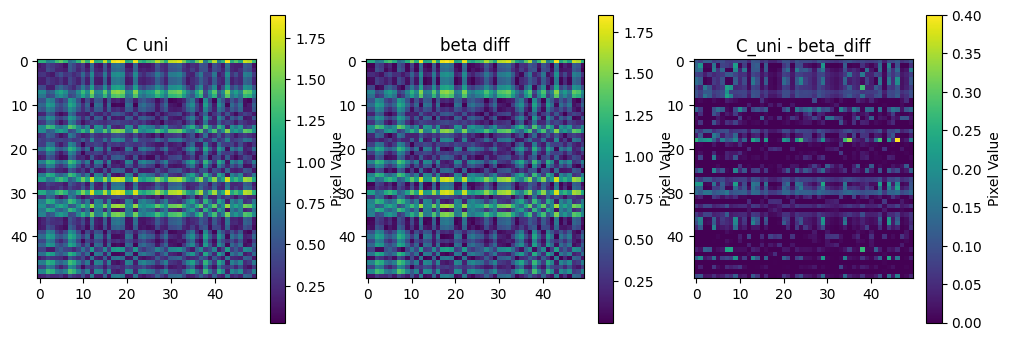

In [14]:
import ot

def calculate_C(W_X_matching, W_Y_matching, a=None, b=None):
  n = W_X_matching.shape[0]
  m = W_Y_matching.shape[0]
# Can also compute for uniform distributions on the distance profiles
  if a is None and b is None:
    a = np.ones(n) / n
    b = np.ones(m) / m
    # Step 1: Initialize W₁ matrix
    W1_matrix = np.zeros((n, m))

    # Step 2: Compute W₁ distances between each pair of weigted distance profiles
    for i in range(n):
        for j in range(m):
              W1_matrix[i, j] = ot.wasserstein_1d(W_X_matching[i], W_Y_matching[j], a, b)
    return W1_matrix

  else:
    W1_matrix = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            W1_matrix[i, j] = ot.wasserstein_1d(W_X_matching[i], W_Y_matching[j], a, b)

    return W1_matrix

W1_matrix_uniform = calculate_C(W_X_matching, W_Y_matching)

interesting = W1_matrix_uniform - diff_beta
matrices = [W1_matrix_uniform, diff_beta, interesting]
titles = ['C uni', 'beta diff', 'C_uni - beta_diff']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))  # 1 row, 3 columns
for i, ax in enumerate(axes):
    im = ax.imshow(matrices[i], cmap='viridis', interpolation='nearest')
    ax.set_title(titles[i])
    # ax.axis('off')  # optional: hide axis ticks
    cbar = plt.colorbar(im)
    cbar.set_label('Pixel Value')  # optional: add label to the bar

#Optimizing our objective for $\pi^\star$

Initialization: objective = -5.61527263554297
Implement fixed point algorithm
max of entropy term :-6.132144090227808 
 max of main term: 0.47246122060251655
Iteration 1: objective = -5.659682869625291, objective relative change = -0.007908829537717797, pi change (L1) = 0.2884354233249551
max of entropy term :-6.134283840846122 
 max of main term: 0.47457100224167925
Iteration 2: objective = -5.6597128386044435, objective relative change = -5.29516933066469e-06, pi change (L1) = 0.007619345140675627
max of entropy term :-6.1342211801127 
 max of main term: 0.47450829779396747
Iteration 3: objective = -5.659712882318733, objective relative change = -7.723764495485537e-09, pi change (L1) = 0.00026937069657002844
max of entropy term :-6.134223495490726 
 max of main term: 0.4745106130583641
Iteration 4: objective = -5.659712882432362, objective relative change = -2.007683225050503e-11, pi change (L1) = 1.152212838334378e-05
max of entropy term :-6.134223393463504 
 max of main term: 0.474

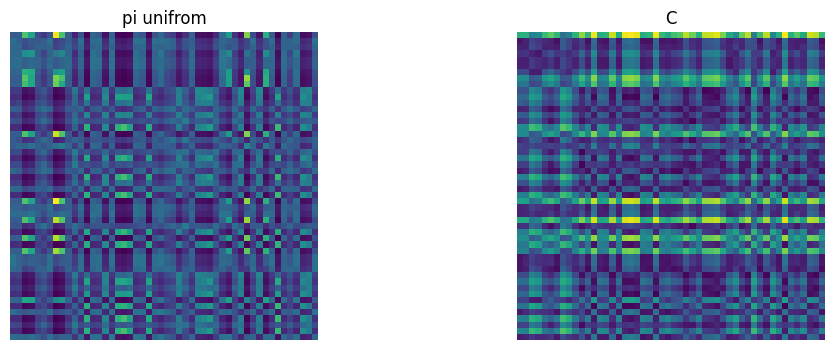

In [ ]:
from matching_clustering.utils import LapOT

# Cost matrix
C = W1_matrix_uniform


# # # Laplacian matrices
K = L_X
L = L_Y


# LapOT
# define the LapOT problem
# w, v set to uniform weights by default if not provided
# solve the problem by the fixed-point (fp) or gradient descent with KL divergence (gdkl)
# verbose=True to print the iteration information
# method='fp' converges fast for lambda above certain threshold
# method='gdkl' converges for any lambda but can be slow
# for method='gdkl', the step size is (tau_scale) * (theoretical threshold)
# providing tau_scale > 1.0 (default=1.0) to take a more aggressive step size may speed up method='gdkl'


# 1. Fixed-point (lambda should not be too small)
# Set lambda_x, lambda_y and lambda
l = 0.7 # lambda
l_x = 4
l_y = 4


prob_2 = LapOT(K, L, C, l, l_x, l_y)
pi_fp_uni = prob_2.solve(method='fp', verbose=True)
# # visualize coupling
# plt.imshow(pi_fp)
# plt.title('Coupling Matrix (fixed-point)')
# plt.colorbar()
# plt.xlabel('Y samples')
# plt.ylabel('X samples')
# plt.show()



matrices = [pi_fp_uni, C]
titles = ['pi unifrom', 'C']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 3 columns
for i, ax in enumerate(axes):
    im = ax.imshow(matrices[i], cmap='viridis', interpolation='nearest')
    ax.set_title(titles[i])
    ax.axis('off')  # optional: hide axis ticks

#Calculate $\pi^X_{switch}$, $\pi^Y_{switch}$ for RSC (Refined Simultaneous Clustering).
##Update the similarity matrices
$$
W^X ⟶ W^X \bullet \pi^X_{switch}
$$

$$
W^Y ⟶ W^Y \bullet \pi^Y_{switch}
$$

In [20]:
from sklearn.cluster import KMeans

# Implement the function that does K means on the rows of a given matrix

def build_cluster_matrix(A: np.ndarray, k: int) -> np.ndarray:
    """
    Clusters the rows of matrix A into k clusters and returns a matrix X such that:
    X[i, j] = 1 if row i and row j are in the same cluster, else 0.
    """
    n = A.shape[0]
    # assert A.shape[0] == A.shape[1], "Matrix A must be square"

    # Convert to NumPy for sklearn

    # Perform KMeans clustering on the rows
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=0)
    labels = kmeans.fit_predict(A)

    # Construct the nxn cluster indicator matrix
    X = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if labels[i] == labels[j]:
                X[i, j] = 1

    return X


##Add $\epsilon$ to $W$ to make itsimilarity matrix of a fully connected graph.

In [21]:
PI_for_X = build_cluster_matrix(pi_fp_uni, 2)
PI_for_Y = build_cluster_matrix(pi_fp_uni.T, 2)
epsilon = 1e-15
new_W_X = PI_for_X*W_X_adjace + epsilon
new_W_Y = PI_for_Y*W_Y_adjace + epsilon

#Next run the two following cells to see the low rank structure of $\pi^\star$

Run the celss regadless, it contained functions needed for the plot later.

In [22]:
import numpy as np

def matrix_to_labels(M):
    """
    Convert an NxN cluster-indicator matrix M (M[i,j] = 1 iff i,j in same cluster)
    into a label vector of length N.
    """
    # Sort unique rows and get inverse index mapping
    # Rows belonging to the same cluster are identical
    _, labels = np.unique(M, axis=0, return_inverse=True)
    return labels



labels_x = matrix_to_labels(PI_for_X)
labels_y = matrix_to_labels(PI_for_Y)



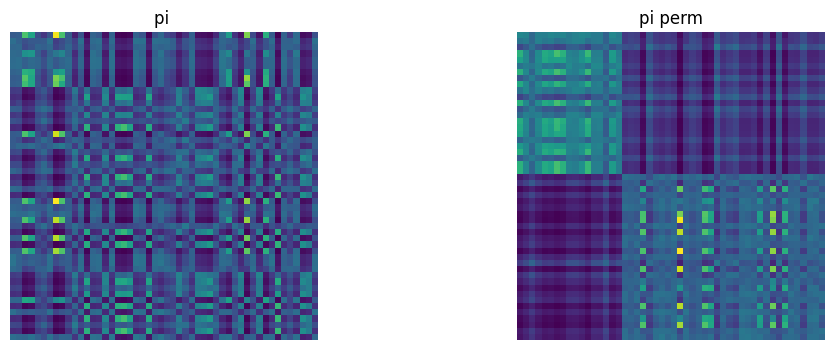

In [23]:
import numpy as np

def group_by_labels(A, x, y):
    """
    Reorder rows and columns of A so that rows with the same label in x
    are contiguous, and columns with the same label in y are contiguous.

    Parameters
    ----------
    A : (n, n) ndarray
        Square matrix.
    x : (n,) array_like
        Row labels.
    y : (n,) array_like
        Column labels.

    Returns
    -------
    A_reordered : (n, n) ndarray
        Matrix with rows and columns reordered.
    row_order : (n,) ndarray
        Indices of original rows in the new order.
    col_order : (n,) ndarray
        Indices of original columns in the new order.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    # Get permutation that groups equal labels together.
    # np.argsort will place identical labels next to each other.
    row_order = np.argsort(x)
    col_order = np.argsort(y)

    A_reordered = A[row_order][:, col_order]
    return A_reordered, row_order, col_order

A_reordered, row_order, col_order = group_by_labels(pi_fp_uni, labels_x, labels_y)


matrices = [pi_fp_uni, A_reordered]
titles = ['pi ', 'pi perm']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 3 columns
for i, ax in enumerate(axes):
    im = ax.imshow(matrices[i], cmap='viridis', interpolation='nearest')
    ax.set_title(titles[i])
    ax.axis('off')  # optional: hide axis ticks

#Refined Spectral Clustering
##Step 1:
Run Spectral Clustering on the basis of the refined similarity matrices and calculate the label matrices for the clustering of both clouds.

In [24]:
import numpy as np
from sklearn.cluster import SpectralClustering

def spectral_same_cluster_matrix(W, n_clusters=5, random_state=0):
    """
    W : (n, n) adjacency / similarity matrix
    n_clusters : number of clusters for spectral clustering

    Returns:
        labels : shape (n,) integer cluster labels
        A      : (n, n) binary same-cluster matrix
                 A[i,j] = 1 iff labels[i] == labels[j]
    """
    n = W.shape[0]

    # Spectral clustering with precomputed affinity
    sc = SpectralClustering(
        n_clusters=n_clusters,
        affinity='precomputed',
        assign_labels='kmeans',
        random_state=random_state,
    )
    labels = sc.fit_predict(W)  # shape (n,)

    # Build same-cluster matrix
    A = (labels[:, None] == labels[None, :]).astype(int)  # (n, n)

    return labels, A


# ----- Usage with your matrices W_X and W_Y -----

# choose number of clusters (change as you like)
k_X = 5
k_Y = 5

labels_X, A = spectral_same_cluster_matrix(new_W_X, n_clusters=k_X)
labels_Y, B = spectral_same_cluster_matrix(new_W_Y, n_clusters=k_Y)


# Optional: inspect how many clusters were actually used
print("Unique clusters in X:", np.unique(labels_X))
print("Unique clusters in Y:", np.unique(labels_Y))


Unique clusters in X: [0 1 2 3 4]
Unique clusters in Y: [0 1 2 3 4]


##Step 2:
 Plot results based on the clustering label matrices, we permute the rows and columns of the optimal coupling $\pi^\star$ according to $\pi^X_{switch}$ and $\pi^Y_{switch}$to see the broad structure of the clusters.

(50, 50)


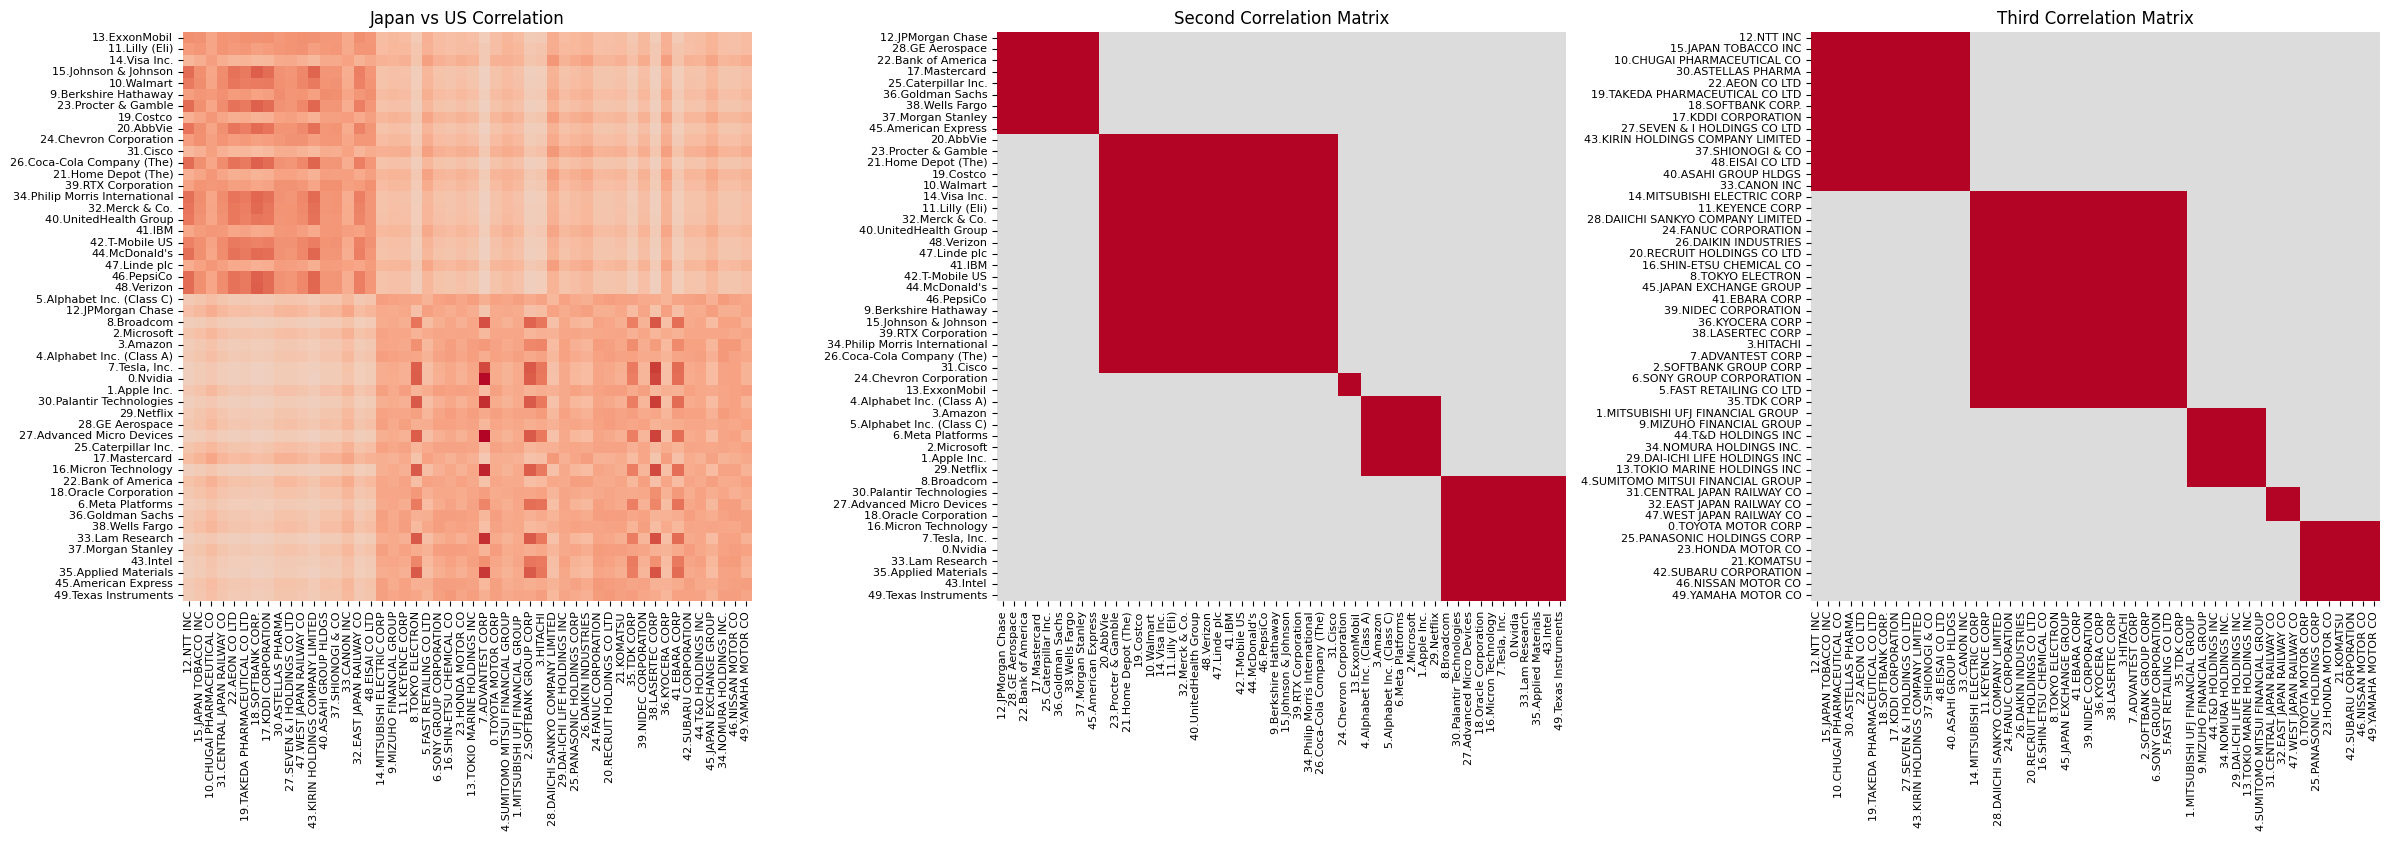

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

A_plot = group_by_labels(A, labels_X, labels_X)[0]
B_plot = group_by_labels(B, labels_Y, labels_Y)[0]


names_US = []
for i in range(50):
  names_US.append(str(i) + '.'+sp500_index_to_name[i])

names_Japan = []
for i in range(50):
  names_Japan.append(str(i) + '.'+japan_index_to_name[i])

M = group_by_labels(pi_fp_uni, labels_X, labels_Y)
print(M[0].shape)
x = np.asarray(labels_x)
y = np.asarray(labels_y)

x_cluster = np.asarray(labels_X)
y_cluster = np.asarray(labels_Y)

# Get permutation that groups equal labels together.
# np.argsort will place identical labels next to each other.
row_order = np.argsort(x)
col_order = np.argsort(y)

order_cluster_US = np.argsort(x_cluster)
order_cluster_Japan = np.argsort(y_cluster)

names_US = np.array(names_US, dtype=object)
names_Japan = np.array(names_Japan, dtype=object)

names_US_reordered = names_US[row_order]
names_Japan_reordered = names_Japan[col_order]

names_US_cluster = names_US[order_cluster_US]
names_Japan_cluster = names_Japan[order_cluster_Japan]




# Create 1 row with 3 columns for the 3 heatmaps
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# --- Heatmap 1 ---
sns.heatmap(
    A_reordered,
    xticklabels=names_Japan_reordered,
    yticklabels=names_US_reordered,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar=False,
    ax=axes[0]
)
axes[0].set_title("Japan vs US Correlation")
axes[0].tick_params(axis='x', rotation=90, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# --- Heatmap 2 ---
sns.heatmap(
    A_plot,                      # <- second matrix
    xticklabels=names_US_cluster,             # <- second x labels
    yticklabels=names_US_cluster,             # <- second y labels
    cmap="coolwarm",
    center=0,
    square=True,
    cbar=False,
    ax=axes[1]
)
axes[1].set_title("Second Correlation Matrix")
axes[1].tick_params(axis='x', rotation=90, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=8)

# --- Heatmap 3 ---
sns.heatmap(
    B_plot,                      # <- third matrix
    xticklabels=names_Japan_cluster,
    yticklabels=names_Japan_cluster,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar=False,
    ax=axes[2]
)
axes[2].set_title("Third Correlation Matrix")
axes[2].tick_params(axis='x', rotation=90, labelsize=8)
axes[2].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.show()